In [1]:
import xarray as xr

ds = xr.open_dataset("gdas.t06z.pgrb2.0p25.f000", engine="cfgrib")

print(ds)

skipping variable: paramId==165 shortName='u10'
Traceback (most recent call last):
  File "c:\Users\MSI\miniconda3\Lib\site-packages\cfgrib\dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
    ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\MSI\miniconda3\Lib\site-packages\cfgrib\dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
    ...<2 lines>...
    )
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='heightAboveGround' value=Variable(dimensions=(), data=np.float64(2.0)) new_value=Variable(dimensions=(), data=np.float64(10.0))
skipping variable: paramId==166 shortName='v10'
Traceback (most recent call last):
  File "c:\Users\MSI\miniconda3\Lib\site-packages\cfgrib\dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
    ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\MSI\miniconda3\Lib\site-packages\cfgrib\dataset.py", line 642, in dict_merge
    raise Datase

<xarray.Dataset> Size: 8MB
Dimensions:            (latitude: 721, longitude: 1440)
Coordinates:
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    surface            float64 8B ...
    valid_time         datetime64[ns] 8B ...
    heightAboveGround  float64 8B ...
Data variables:
    t                  (latitude, longitude) float32 4MB ...
    t2m                (latitude, longitude) float32 4MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-22T16:32 GRIB to CDM+CF via cfgrib-0.9.1...


In [2]:
temp = ds['t2m']
print(temp.values)

[[249.71284 249.71284 249.71284 ... 249.71284 249.71284 249.71284]
 [250.11284 250.11284 250.11284 ... 250.11284 250.11284 250.11284]
 [250.21284 250.21284 250.21284 ... 250.21284 250.21284 250.21284]
 ...
 [221.11284 221.11284 221.11284 ... 221.11284 221.11284 221.11284]
 [221.21284 221.21284 221.21284 ... 221.21284 221.21284 221.21284]
 [219.91284 219.91284 219.91284 ... 219.91284 219.91284 219.91284]]


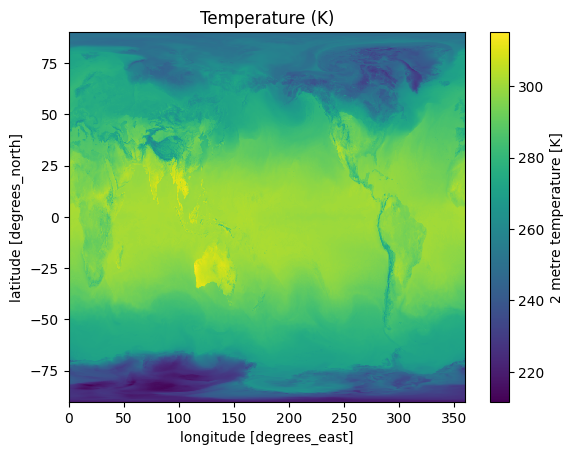

In [4]:
import matplotlib.pyplot as plt

temp.plot()
plt.title("Temperature (K)")
plt.show()

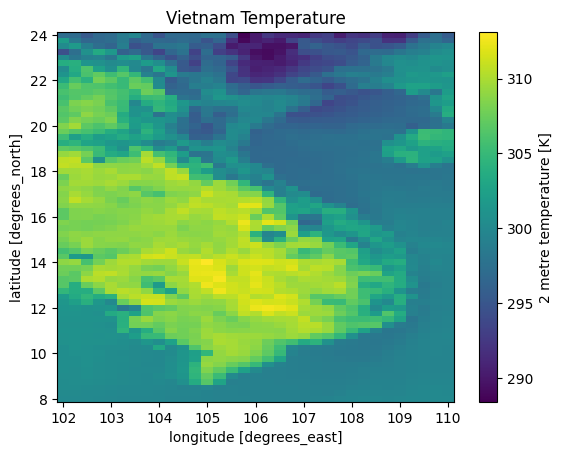

In [5]:
subset = ds.sel(
    latitude=slice(24, 8),
    longitude=slice(102, 110)
)

subset['t2m'].plot()
plt.title("Vietnam Temperature")
plt.show()

In [ ]:
import json
import numpy as np

raw_data = np.round(subset["t2m"].values - 273.15, 1)
data = [[float(f"{v:.1f}") for v in row] for row in raw_data]
lat = [float(f"{v:.2f}") for v in subset["latitude"].values]
lon = [float(f"{v:.2f}") for v in subset["longitude"].values]

result = {
    "lat": lat,
    "lon": lon,
    "data": data,
}

def format_compact_json(obj: dict) -> str:
    lat_s = json.dumps(obj["lat"], ensure_ascii=False)
    lon_s = json.dumps(obj["lon"], ensure_ascii=False)
    data_rows = [json.dumps(row, ensure_ascii=False) for row in obj["data"]]
    data_s = "[\n    " + ",\n    ".join(data_rows) + "\n  ]"

    return "{\n" + \
        f'  "lat": {lat_s},\n' + \
        f'  "lon": {lon_s},\n' + \
        f'  "data": {data_s}\n' + \
        "}\n"

with open("temperature.json", "w", encoding="utf-8") as f:
    f.write(format_compact_json(result))

In [23]:
print("len(lat) =", len(lat))
print("len(lon) =", len(lon))
print("shape(data) =", np.array(data).shape)

len(lat) = 65
len(lon) = 33
shape(data) = (65, 33)


## Preview nhiet do tren ban do
Cell nay doc `temperature.json`, tao lop mau nhiet do, va overlay len ban do de ban kiem tra style.

Saved map to: temperature_preview_map_labeled.html
Saved labeled overlay PNG: temperature_overlay_labeled.png
Input grid: (65, 33), Smoothed grid: (650, 512)
Bounds: lat 8.00..24.00, lon 102.00..110.00



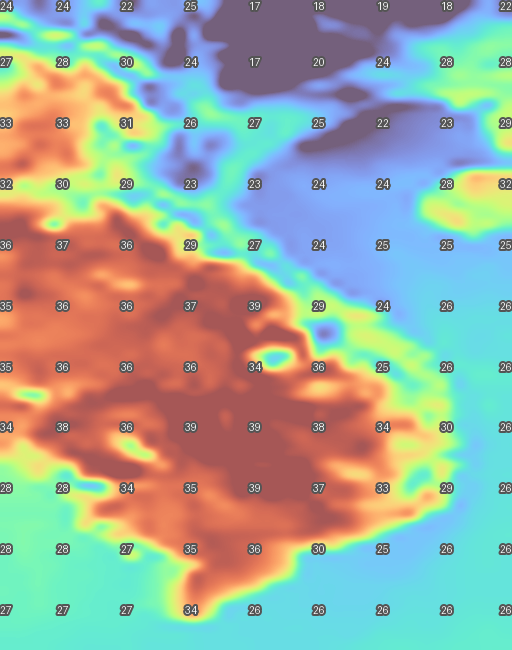

In [7]:
import json
import numpy as np
import matplotlib.colors as mcolors

# Auto-install folium + pillow if missing (run once)
try:
    import folium
    from branca.colormap import LinearColormap
    from PIL import Image, ImageDraw, ImageFont
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "folium", "pillow", "branca", "-q"])
    import folium
    from branca.colormap import LinearColormap
    from PIL import Image, ImageDraw, ImageFont

# 1) Read temperature grid from your exported JSON
with open("temperature.json", "r", encoding="utf-8") as f:
    obj = json.load(f)

lats = np.array(obj["lat"], dtype=float)
lons = np.array(obj["lon"], dtype=float)
vals = np.array(obj["data"], dtype=float)

# Ensure arrays are geospatially consistent for both image and labels
if lats[0] < lats[-1]:
    vals = np.flipud(vals)
    lats = lats[::-1]
if lons[0] > lons[-1]:
    vals = np.fliplr(vals)
    lons = lons[::-1]

south, north = float(np.min(lats)), float(np.max(lats))
west, east = float(np.min(lons)), float(np.max(lons))

# 2) Smooth/interpolate in value-space before coloring
smooth_factor = 10  # tang de muot hon, giam de sac net hon
target_h = max(512, vals.shape[0] * smooth_factor)
target_w = max(512, vals.shape[1] * smooth_factor)

vals_img = Image.fromarray(vals.astype(np.float32), mode="F")
vals_img = vals_img.resize((target_w, target_h), resample=Image.Resampling.BICUBIC)
vals_hi = np.array(vals_img, dtype=np.float32)

# Optional anti-block look using pure numpy (avoids Pillow mode errors)
def box_blur_once(arr: np.ndarray) -> np.ndarray:
    p = np.pad(arr, ((1, 1), (1, 1)), mode="edge")
    return (
        p[:-2, :-2] + p[:-2, 1:-1] + p[:-2, 2:] +
        p[1:-1, :-2] + p[1:-1, 1:-1] + p[1:-1, 2:] +
        p[2:, :-2] + p[2:, 1:-1] + p[2:, 2:]
    ) / 9.0

blur_passes = 1
for _ in range(blur_passes):
    vals_hi = box_blur_once(vals_hi)

# 3) Custom temperature-to-color style
vmin = float(np.nanpercentile(vals, 5))
vmax = float(np.nanpercentile(vals, 95))
if np.isclose(vmin, vmax):
    vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax, clip=True)
cmap = np.asarray(__import__("matplotlib").colormaps["turbo"](norm(vals_hi)) * 255, dtype=np.uint8)

rgba = cmap.copy()
rgba[..., 3] = 170  # alpha for transparency
rgba[np.isnan(vals_hi), 3] = 0

# 4) Draw numeric temperature labels directly on tile image
show_value_labels = True
if show_value_labels:
    overlay = Image.fromarray(rgba, mode="RGBA")
    draw = ImageDraw.Draw(overlay)
    font = ImageFont.load_default()
    h, w = rgba.shape[:2]

    label_step_lat = max(1, len(lats) // 10)
    label_step_lon = max(1, len(lons) // 8)

    for i in range(0, len(lats), label_step_lat):
        for j in range(0, len(lons), label_step_lon):
            t = vals[i, j]
            if np.isnan(t):
                continue

            lon_v = float(lons[j])
            lat_v = float(lats[i])
            x = int((lon_v - west) / (east - west) * (w - 1))
            y = int((north - lat_v) / (north - south) * (h - 1))

            text = f"{t:.0f}"
            bbox = draw.textbbox((0, 0), text, font=font)
            tw = bbox[2] - bbox[0]
            th = bbox[3] - bbox[1]
            tx = max(0, min(w - tw, x - tw // 2))
            ty = max(0, min(h - th, y - th // 2))

            draw.text(
                (tx, ty),
                text,
                fill=(255, 255, 255, 245),
                font=font,
                stroke_width=2,
                stroke_fill=(0, 0, 0, 170),
            )

    rgba = np.array(overlay, dtype=np.uint8)

# Save snapshot (optional)
Image.fromarray(rgba, mode="RGBA").save("temperature_overlay_labeled.png")

# 5) Build map + overlay
center_lat = (south + north) / 2
center_lon = (west + east) / 2

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=6,
    tiles="CartoDB positron"
 )

folium.raster_layers.ImageOverlay(
    image=rgba,
    bounds=[[south, west], [north, east]],
    name="Temperature overlay",
    opacity=0.75,
    interactive=True,
    cross_origin=False,
    zindex=1,
).add_to(m)

legend = LinearColormap(
    colors=["#2c7bb6", "#abd9e9", "#ffffbf", "#fdae61", "#d7191c"],
    vmin=vmin,
    vmax=vmax,
    caption="Temperature (degC)",
)
legend.add_to(m)
folium.LayerControl().add_to(m)

out_html = "temperature_preview_map_labeled.html"
m.save(out_html)
print(f"Saved map to: {out_html}")
print("Saved labeled overlay PNG: temperature_overlay_labeled.png")
print(f"Input grid: {vals.shape}, Smoothed grid: {vals_hi.shape}")
print(f"Bounds: lat {south:.2f}..{north:.2f}, lon {west:.2f}..{east:.2f}")
m

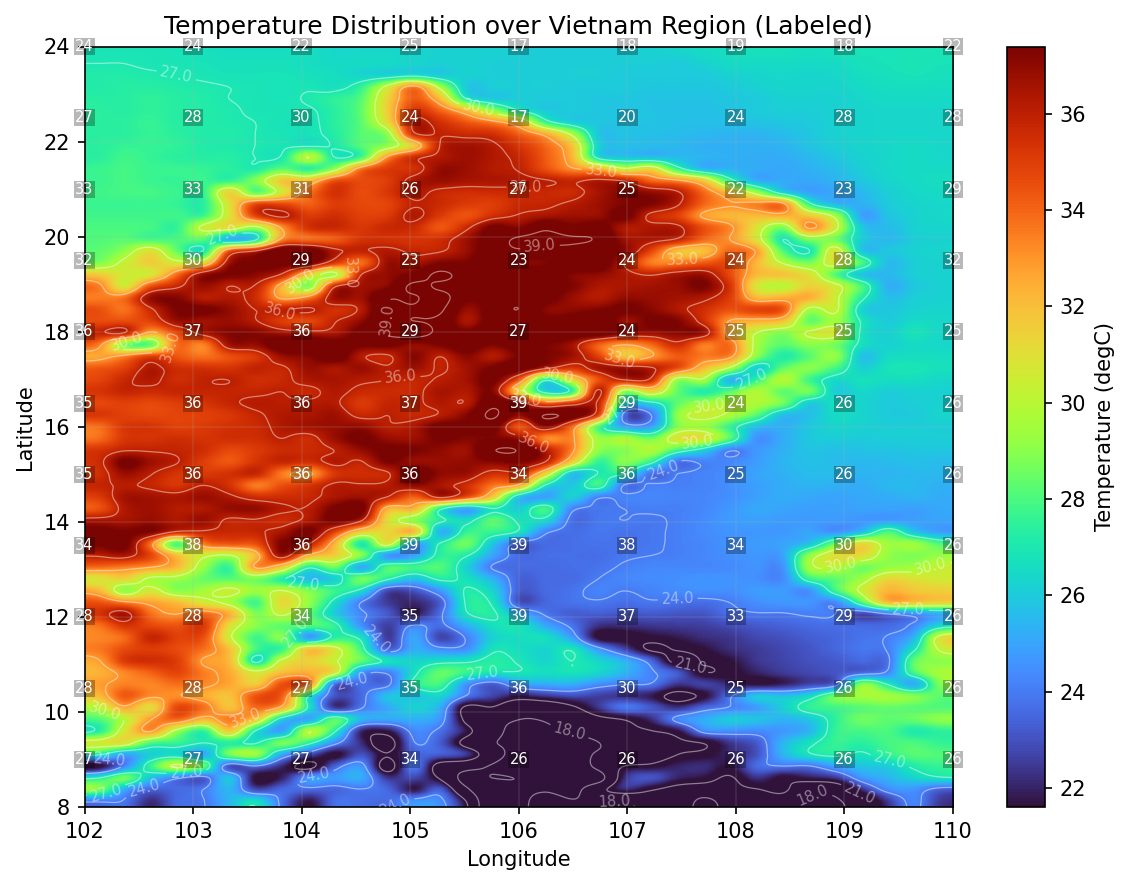

Saved image to: temperature_distribution_labeled.png


In [8]:
import matplotlib.pyplot as plt

# Hien thi phan bo nhiet do tren anh 2D (kinh do - vi do)
plt.figure(figsize=(8, 6), dpi=150)

im = plt.imshow(
    vals_hi,
    extent=[west, east, south, north],
    origin="lower",
    cmap="turbo",
    vmin=vmin,
    vmax=vmax,
    aspect="auto",
)

# Them duong dong muc de nhin ro gradient nhiet do
contour = plt.contour(
    np.linspace(west, east, vals_hi.shape[1]),
    np.linspace(south, north, vals_hi.shape[0]),
    vals_hi,
    levels=8,
    colors="white",
    linewidths=0.6,
    alpha=0.45,
 )
plt.clabel(contour, inline=True, fontsize=7, fmt="%.1f")

# Hien thi so nhiet do tai cac diem mau goc de giai thich mau
text_step_lat = max(1, len(lats) // 10)
text_step_lon = max(1, len(lons) // 8)
for i in range(0, len(lats), text_step_lat):
    for j in range(0, len(lons), text_step_lon):
        t = vals[i, j]
        if np.isnan(t):
            continue
        plt.text(
            lons[j],
            lats[i],
            f"{t:.0f}",
            color="white",
            fontsize=7,
            ha="center",
            va="center",
            bbox={"facecolor": "black", "alpha": 0.28, "pad": 0.5, "edgecolor": "none"},
        )

cbar = plt.colorbar(im)
cbar.set_label("Temperature (degC)")
plt.title("Temperature Distribution over Vietnam Region (Labeled)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.15)
plt.tight_layout()

out_img = "temperature_distribution_labeled.png"
plt.savefig(out_img, bbox_inches="tight")
plt.show()
print(f"Saved image to: {out_img}")

=== DEMO INTERPOLATION STATS ===
Original grid: 6 x 6 = 36 points
Interpolated grid: 60 x 60 = 3600 points
Added points: 3564
Point density ratio: 100.0x


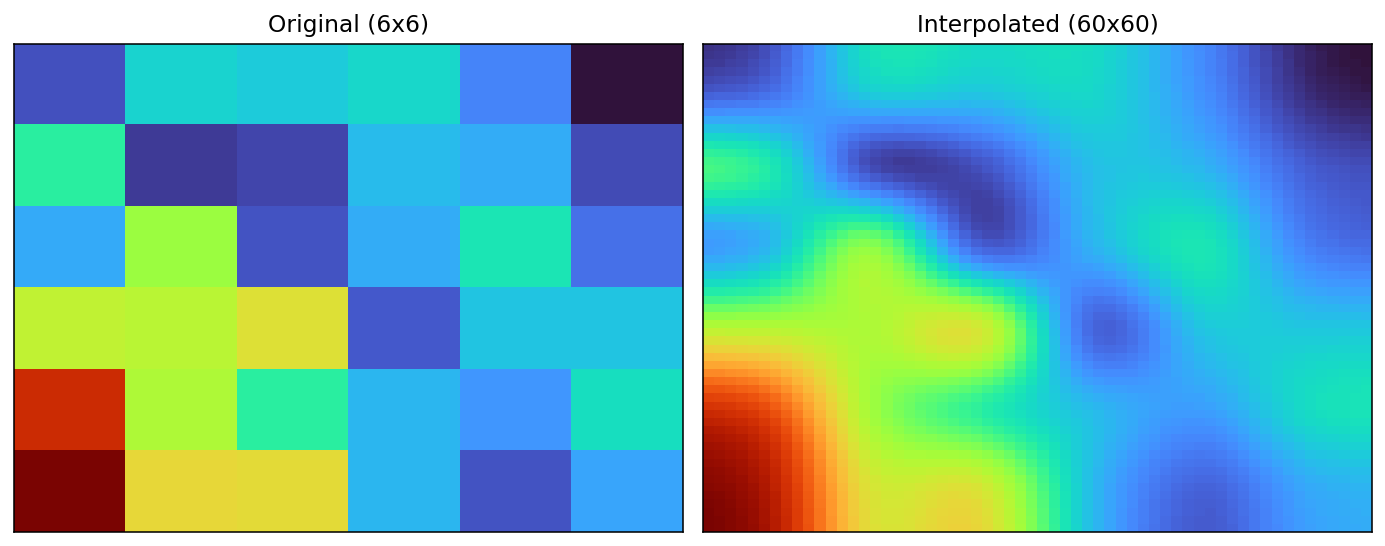

In [9]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Demo: cat mot vung nho tu du lieu goc va noi suy len luoi day hon
row_start, row_end = 20, 26   # 6 hang
col_start, col_end = 10, 16   # 6 cot
demo_factor = 10               # he so tang mat do

small = vals[row_start:row_end, col_start:col_end]
small_h, small_w = small.shape
orig_points = small_h * small_w

# Noi suy bicubic thong qua resize tren value-grid
small_img = Image.fromarray(small.astype(np.float32), mode="F")
interp_img = small_img.resize(
    (small_w * demo_factor, small_h * demo_factor),
    resample=Image.Resampling.BICUBIC,
 )
small_interp = np.array(interp_img, dtype=np.float32)

new_h, new_w = small_interp.shape
new_points = new_h * new_w
added_points = new_points - orig_points
ratio = new_points / orig_points

print("=== DEMO INTERPOLATION STATS ===")
print(f"Original grid: {small_h} x {small_w} = {orig_points} points")
print(f"Interpolated grid: {new_h} x {new_w} = {new_points} points")
print(f"Added points: {added_points}")
print(f"Point density ratio: {ratio:.1f}x")

# Ve so sanh truoc/sau de ban nhin truc quan
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=140)
axes[0].imshow(small, cmap="turbo", aspect="auto")
axes[0].set_title(f"Original ({small_h}x{small_w})")
axes[1].imshow(small_interp, cmap="turbo", aspect="auto")
axes[1].set_title(f"Interpolated ({new_h}x{new_w})")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

In [15]:
ds_u10 = xr.open_dataset(
    "gdas.t06z.pgrb2.0p25.f000",
    engine="cfgrib",
    backend_kwargs={"filter_by_keys": {"shortName": "10u"}}
)
ds_v10 = xr.open_dataset(
    "gdas.t06z.pgrb2.0p25.f000",
    engine="cfgrib",
    backend_kwargs={"filter_by_keys": {"shortName": "10v"}}
)


## Windy-like wind map
Cell nay doc du lieu gio `10u/10v`, tinh toc do gio, ve streamlines va overlay len ban do Folium.

Saved wind map HTML: windy_preview_map.html
Saved wind overlay PNG: windy_overlay.png
Saved wind static PNG: windy_static.png
Speed range for color scale: 0.96..6.72 m/s



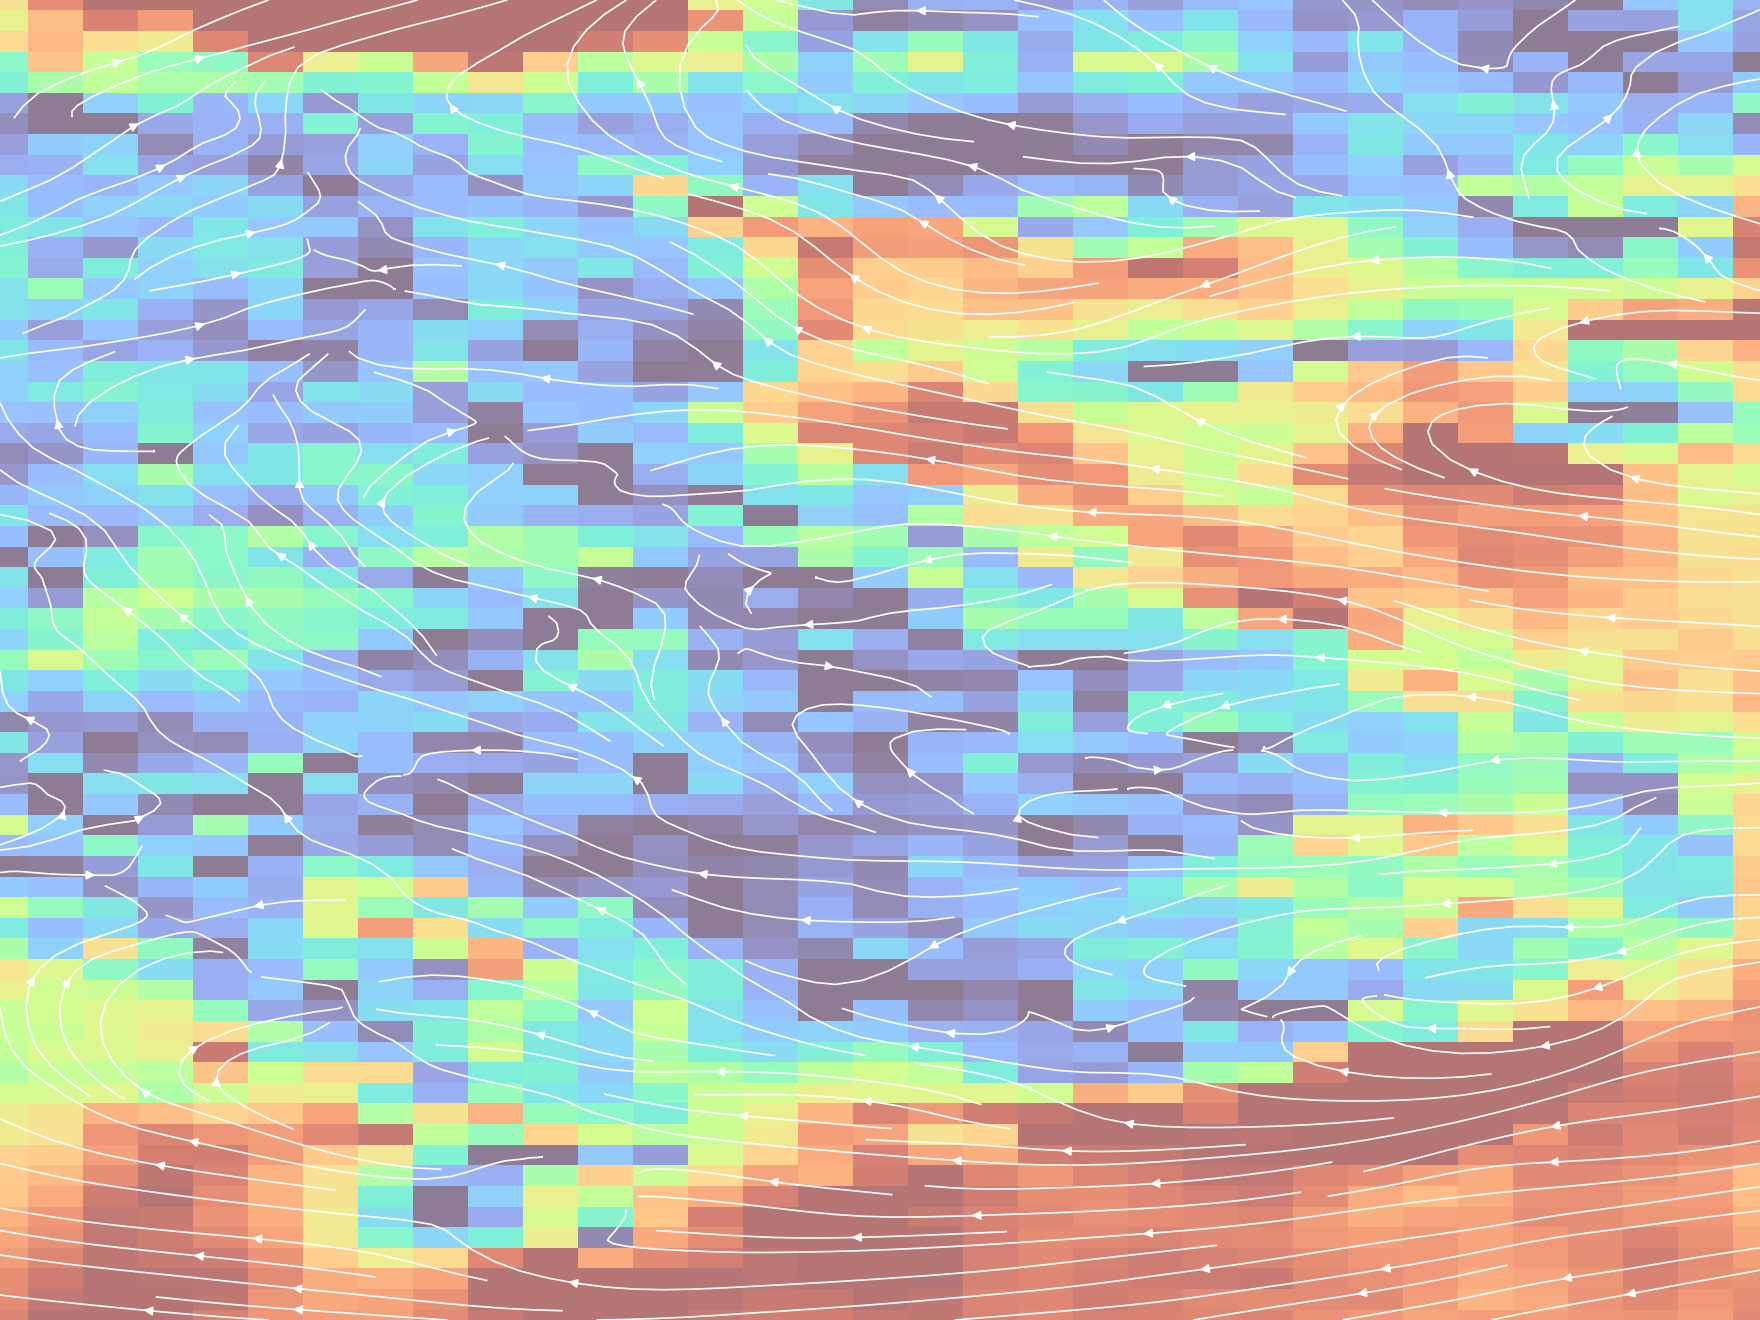

In [18]:
import io
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

try:
    import folium
    from branca.colormap import LinearColormap
    from PIL import Image
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "folium", "branca", "pillow", "-q"])
    import folium
    from branca.colormap import LinearColormap
    from PIL import Image

file_path = "gdas.t06z.pgrb2.0p25.f000"

# 1) Load U/V wind components at 10m
ds_u10 = xr.open_dataset(
    file_path,
    engine="cfgrib",
    backend_kwargs={"filter_by_keys": {"shortName": "10u"}},
)
ds_v10 = xr.open_dataset(
    file_path,
    engine="cfgrib",
    backend_kwargs={"filter_by_keys": {"shortName": "10v"}},
)

u = ds_u10["u10"].sel(latitude=slice(24, 8), longitude=slice(102, 110)).values
v = ds_v10["v10"].sel(latitude=slice(24, 8), longitude=slice(102, 110)).values
lat = ds_u10["latitude"].sel(latitude=slice(24, 8)).values
lon = ds_u10["longitude"].sel(longitude=slice(102, 110)).values

# Streamplot requires latitude axis in ascending order
if lat[0] > lat[-1]:
    lat = lat[::-1]
    u = u[::-1, :]
    v = v[::-1, :]

speed = np.sqrt(u ** 2 + v ** 2)
vmin_w = float(np.nanpercentile(speed, 5))
vmax_w = float(np.nanpercentile(speed, 95))

# 2) Create transparent windy-like overlay image
fig, ax = plt.subplots(figsize=(8, 6), dpi=220)
fig.patch.set_alpha(0.0)
ax.set_facecolor((0, 0, 0, 0))

ax.pcolormesh(
    lon, lat, speed, cmap="turbo", shading="auto", alpha=0.55, vmin=vmin_w, vmax=vmax_w
)
ax.streamplot(
    lon, lat, u, v,
    color="white",
    density=2.0,
    linewidth=0.55,
    arrowsize=0.6,
    minlength=0.15,
    maxlength=4.0,
)

ax.set_xlim(float(lon.min()), float(lon.max()))
ax.set_ylim(float(lat.min()), float(lat.max()))
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout(pad=0)

wind_overlay_png = "windy_overlay.png"
fig.savefig(wind_overlay_png, dpi=220, transparent=True, bbox_inches="tight", pad_inches=0)
plt.close(fig)

# 3) Save a debug/static plot with axes + colorbar
fig2, ax2 = plt.subplots(figsize=(8, 6), dpi=150)
mesh2 = ax2.pcolormesh(lon, lat, speed, cmap="turbo", shading="auto", vmin=vmin_w, vmax=vmax_w)
ax2.streamplot(lon, lat, u, v, color="white", density=1.7, linewidth=0.7, arrowsize=0.7)
cbar = fig2.colorbar(mesh2, ax=ax2)
cbar.set_label("Wind speed (m/s)")
ax2.set_title("Wind Speed + Streamlines (Windy-like)")
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.grid(alpha=0.15)
plt.tight_layout()
wind_static_png = "windy_static.png"
fig2.savefig(wind_static_png, bbox_inches="tight")
plt.close(fig2)

# 4) Overlay onto folium map
south, north = float(lat.min()), float(lat.max())
west, east = float(lon.min()), float(lon.max())
center_lat = (south + north) / 2
center_lon = (west + east) / 2

overlay_rgba = np.array(Image.open(wind_overlay_png).convert("RGBA"))
m_wind = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles="CartoDB positron")
folium.raster_layers.ImageOverlay(
    image=overlay_rgba,
    bounds=[[south, west], [north, east]],
    name="Windy overlay",
    opacity=0.9,
    interactive=True,
    zindex=2,
).add_to(m_wind)

legend = LinearColormap(
    colors=["#2c7bb6", "#00a6ca", "#00ccbc", "#90eb9d", "#f9d057", "#f29e2e", "#e76818", "#d7191c"],
    vmin=vmin_w,
    vmax=vmax_w,
    caption="Wind speed (m/s)",
)
legend.add_to(m_wind)
folium.LayerControl().add_to(m_wind)

wind_html = "windy_preview_map.html"
m_wind.save(wind_html)

print(f"Saved wind map HTML: {wind_html}")
print(f"Saved wind overlay PNG: {wind_overlay_png}")
print(f"Saved wind static PNG: {wind_static_png}")
print(f"Speed range for color scale: {vmin_w:.2f}..{vmax_w:.2f} m/s")
m_wind